In [187]:
import pandas as pd
from scipy.io import arff
from patsy import dmatrices
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,StratifiedKFold, KFold, cross_val_predict, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score




In [2]:


# Load ARFF file
data = arff.loadarff('credit.arff')

df = pd.DataFrame(data[0])


for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode("utf-8")

In [15]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6.0,critical/other existing credit,radio/tv,1169.0,0,4,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,1,1
1,2,48.0,existing paid,radio/tv,5951.0,1,2,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,1,0
2,0,12.0,critical/other existing credit,education,2096.0,1,3,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,1,1
3,1,42.0,existing paid,furniture/equipment,7882.0,1,3,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,1,1
4,1,24.0,delayed previously,new car,4870.0,1,2,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,1,0


In [16]:
df_final.head()

,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,num_dependents,...,property_magnitude_real estate,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_yes,foreign_worker_1
0,1,6.0,1169.0,0,4,4.0,4.0,67.0,2.0,1.0,...,1,1,0,1,0,1,0,0,1,1
1,2,48.0,5951.0,1,2,2.0,2.0,22.0,1.0,1.0,...,1,1,0,1,0,1,0,0,0,1
2,0,12.0,2096.0,1,3,2.0,3.0,49.0,1.0,2.0,...,1,1,0,1,0,0,0,1,0,1
3,1,42.0,7882.0,1,3,2.0,4.0,45.0,1.0,2.0,...,0,1,0,0,0,1,0,0,0,1
4,1,24.0,4870.0,1,2,3.0,4.0,53.0,2.0,2.0,...,0,1,0,0,0,1,0,0,0,1


In [23]:
ha_null = df.isnull().any()  
ha_null


checking_status           False
duration                  False
credit_history            False
purpose                   False
credit_amount             False
savings_status            False
employment                False
installment_commitment    False
personal_status           False
other_parties             False
residence_since           False
property_magnitude        False
age                       False
other_payment_plans       False
housing                   False
existing_credits          False
job                       False
num_dependents            False
own_telephone             False
foreign_worker            False
class                     False
dtype: bool

In [36]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

In [29]:
print(df.dtypes)

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object


In [33]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   checking_status                                1000 non-null   int64  
 1   duration                                       1000 non-null   float64
 2   credit_amount                                  1000 non-null   float64
 3   savings_status                                 1000 non-null   int64  
 4   employment                                     1000 non-null   int64  
 5   installment_commitment                         1000 non-null   float64
 6   residence_since                                1000 non-null   float64
 7   age                                            1000 non-null   float64
 8   existing_credits                               1000 non-null   float64
 9   num_dependents                                 1000 n

class
1    700
0    300
Name: count, dtype: int64


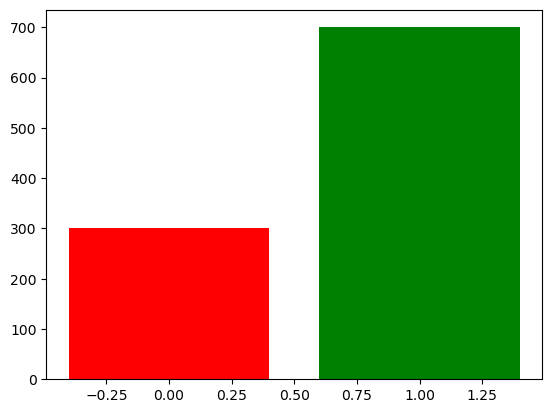

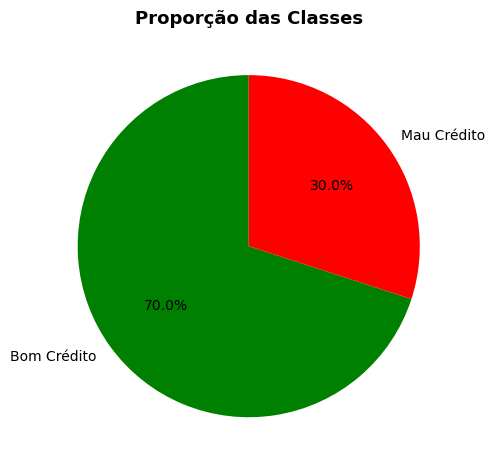

Isso significa que se chutarmos que todos são bons pagadores teremos 70% de acerto. Então um método bom deve ter acurácia maior que 70% para ser válido


In [158]:
counts = df['class'].value_counts()
print(counts)
plt.figure()
plt.bar(counts.index, counts.values, color=['green', 'red'])
plt.show
plt.figure()
plt.pie(counts.values, labels=['Bom Crédito', 'Mau Crédito'],
            colors=['green', 'red'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Isso significa que se chutarmos que todos são bons pagadores teremos 70% de acerto. Então um método bom deve ter acurácia maior que 70% para ser válido')


In [34]:
for coluna in df.select_dtypes(include='object'):
    print(f'{coluna}: {set(df[coluna])}')

checking_status: {'no checking', '<0', '>=200', '0<=X<200'}
credit_history: {'existing paid', 'critical/other existing credit', 'no credits/all paid', 'delayed previously', 'all paid'}
purpose: {'furniture/equipment', 'radio/tv', 'new car', 'repairs', 'other', 'used car', 'domestic appliance', 'retraining', 'business', 'education'}
savings_status: {'no known savings', '100<=X<500', '<100', '500<=X<1000', '>=1000'}
employment: {'1<=X<4', '<1', 'unemployed', '4<=X<7', '>=7'}
personal_status: {'male div/sep', 'male single', 'male mar/wid', 'female div/dep/mar'}
other_parties: {'guarantor', 'co applicant', 'none'}
property_magnitude: {'real estate', 'life insurance', 'car', 'no known property'}
other_payment_plans: {'stores', 'bank', 'none'}
housing: {'rent', 'for free', 'own'}
job: {'unemp/unskilled non res', 'high qualif/self emp/mgmt', 'skilled', 'unskilled resident'}
own_telephone: {'yes', 'none'}
foreign_worker: {'no', 'yes'}
class: {'bad', 'good'}


In [26]:
formula = 'class ~ ' + ' + '.join(
    col for col in df_final.columns if col != 'class'
)

print(formula)

class ~ checking_status + duration + credit_amount + savings_status + employment + installment_commitment + residence_since + age + existing_credits + num_dependents + credit_history_critical/other existing credit + credit_history_delayed previously + credit_history_existing paid + credit_history_no credits/all paid + purpose_domestic appliance + purpose_education + purpose_furniture/equipment + purpose_new car + purpose_other + purpose_radio/tv + purpose_repairs + purpose_retraining + purpose_used car + personal_status_male div/sep + personal_status_male mar/wid + personal_status_male single + other_parties_guarantor + other_parties_none + property_magnitude_life insurance + property_magnitude_no known property + property_magnitude_real estate + other_payment_plans_none + other_payment_plans_stores + housing_own + housing_rent + job_skilled + job_unemp/unskilled non res + job_unskilled resident + own_telephone_yes + foreign_worker_1


In [5]:
df['class'] = (df['class'] == 'good').astype(int)

In [6]:

# 1. Variáveis Ordinais (Substituição por dicionário)
df['checking_status'] = df['checking_status'].map({'no checking': 0, '<0': 1, '0<=X<200': 2, '>=200': 3})
df['savings_status'] = df['savings_status'].map({'no known savings': 0, '<100': 1, '100<=X<500': 2, '500<=X<1000': 3, '>=1000': 4})
df['employment'] = df['employment'].map({'unemployed': 0, '<1': 1, '1<=X<4': 2, '4<=X<7': 3, '>=7': 4})


In [8]:
# 2. Variáveis Nominais
colunas_nominais = [
    'credit_history', 'purpose', 'personal_status', 'other_parties', 
    'property_magnitude', 'other_payment_plans', 'housing', 'job', 
    'own_telephone', 'foreign_worker'
]

# Transforma em colunas 0 e 1, descartando a primeira categoria de cada
df_final = pd.get_dummies(df, columns=colunas_nominais, drop_first=True, dtype=int)


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Etapa 1: Padronização
    ('modelo', LogisticRegression(max_iter=1000)) # Etapa 2: O algoritmo
])

In [22]:
y = df_final['class']
X = df_final.drop(columns=['class'])

In [29]:
df_final.shape

(1000, 41)

In [36]:
# Mostra quantos valores diferentes existem em cada coluna
print(df_final.nunique())



checking_status                                    4
duration                                          33
credit_amount                                    921
savings_status                                     5
employment                                         5
installment_commitment                             4
residence_since                                    4
age                                               53
existing_credits                                   4
num_dependents                                     2
class                                              2
credit_history_critical/other existing credit      2
credit_history_delayed previously                  2
credit_history_existing paid                       2
credit_history_no credits/all paid                 2
purpose_domestic appliance                         2
purpose_education                                  2
purpose_furniture/equipment                        2
purpose_new car                               

In [180]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1,  stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train)

predicoes = modelo.predict(X_test_scaled)

print(f"Acurácia: {accuracy_score(y_test, predicoes):.5f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, predicoes))

# Mostra o número exato de iterações realizadas
print(f"O modelo convergiu em {modelo.n_iter_[0]} iterações.")

results.append(accuracy_score(y_test, predicoes))

Acurácia: 0.71500

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.54      0.37      0.44        60
           1       0.76      0.86      0.81       140

    accuracy                           0.71       200
   macro avg       0.65      0.62      0.62       200
weighted avg       0.69      0.71      0.70       200

O modelo convergiu em 18 iterações.


In [179]:
results = []

In [188]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000))
])

# K-fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_kfold = cross_val_predict(pipeline, X, y, cv=kf)


prob_kfold = cross_val_predict(pipeline, X, y, cv=kf, method='predict_proba')[:, 1]
print(f"AUC-ROC (K-Fold): {roc_auc_score(y, prob_kfold):.4f}")

print("KFold")
print(classification_report(y, pred_kfold))
print("Accuracy:", accuracy_score(y, pred_kfold))
results.append(accuracy_score(y, pred_kfold))

# Leave One Out Cross Validation (LOOCV)
loo = LeaveOneOut()
pred_loocv = cross_val_predict(pipeline, X, y, cv=loo)

print("\nLOOCV")
print(classification_report(y, pred_loocv))
print("Accuracy:", accuracy_score(y, pred_loocv))
results.append(accuracy_score(y, pred_loocv))

AUC-ROC (K-Fold): 0.7375
KFold
              precision    recall  f1-score   support

           0       0.57      0.41      0.47       300
           1       0.77      0.87      0.82       700

    accuracy                           0.73      1000
   macro avg       0.67      0.64      0.65      1000
weighted avg       0.71      0.73      0.72      1000

Accuracy: 0.73

LOOCV
              precision    recall  f1-score   support

           0       0.55      0.36      0.43       300
           1       0.76      0.87      0.81       700

    accuracy                           0.72      1000
   macro avg       0.65      0.62      0.62      1000
weighted avg       0.70      0.72      0.70      1000

Accuracy: 0.719


([<matplotlib.axis.XTick at 0x7aec7f26efd0>,
 [Text(0, 0, '25%'), Text(1, 0, 'K-Fold'), Text(2, 0, 'LOOCV')])

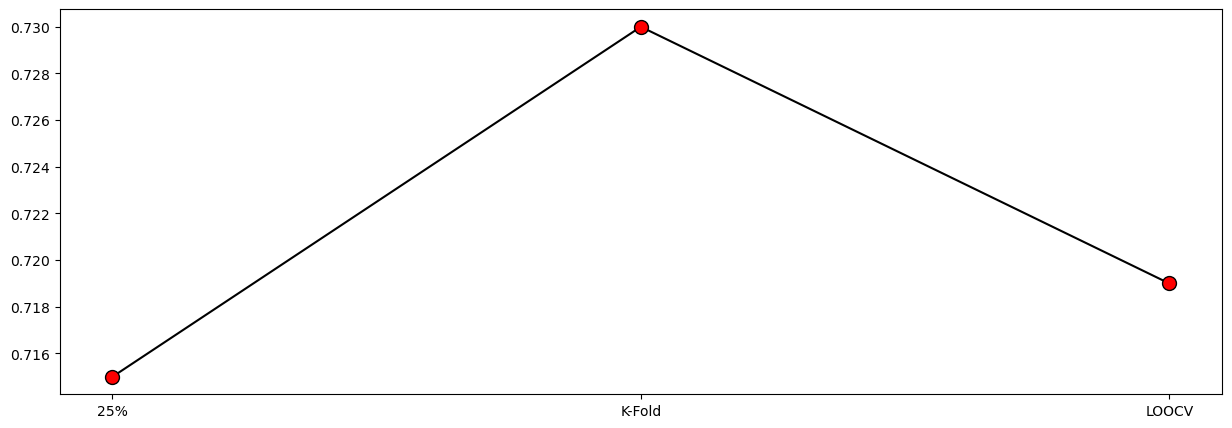

In [182]:
import matplotlib.pyplot as plt
metodos = ['25%','K-Fold','LOOCV']

plt.figure(figsize=(15,5))
plt.plot(results, marker = 'o', c='black', mfc='red', ms=10)
plt.xticks(range(len(metodos)), metodos)

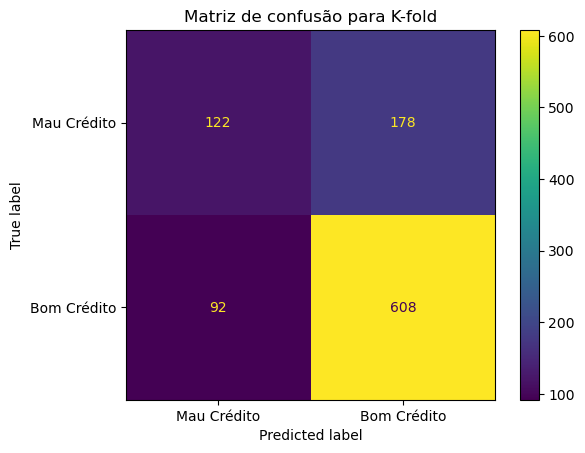

In [185]:
cm = confusion_matrix(y, pred_kfold)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Mau Crédito', 'Bom Crédito']
)

disp.plot()
plt.title("Matriz de confusão para K-fold")
plt.show()

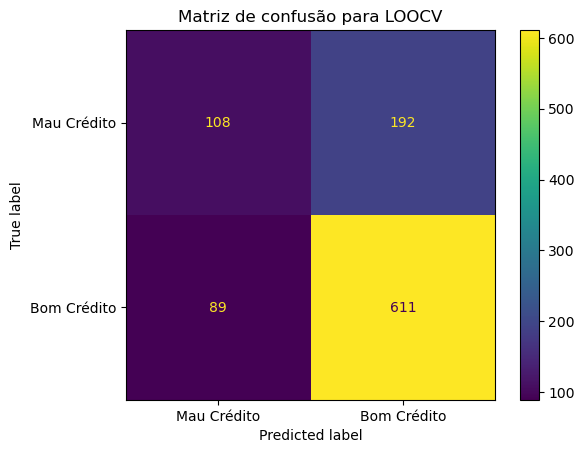

In [184]:
cm = confusion_matrix(y, pred_loocv)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Mau Crédito', 'Bom Crédito']
)

disp.plot()
plt.title("Matriz de confusão para LOOCV")
plt.show()

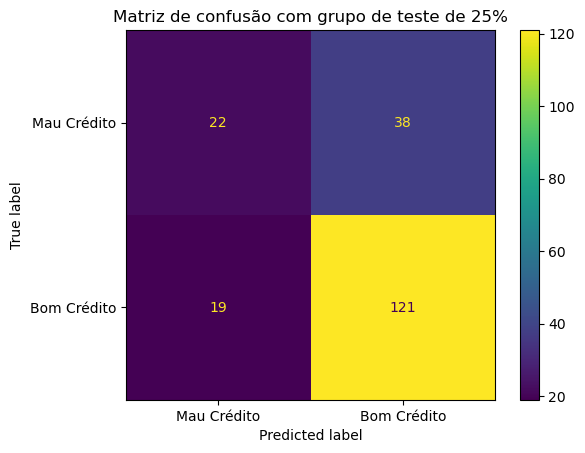

In [183]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes,
    display_labels=['Mau Crédito', 'Bom Crédito']

)
plt.title('Matriz de confusão com grupo de teste de 25%')
plt.show()